In [2]:
from preamble_jax import *
from scipy.optimize import curve_fit

Available devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5), CpuDevice(id=6), CpuDevice(id=7), CpuDevice(id=8), CpuDevice(id=9), CpuDevice(id=10), CpuDevice(id=11)]
CPU devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5), CpuDevice(id=6), CpuDevice(id=7), CpuDevice(id=8), CpuDevice(id=9), CpuDevice(id=10), CpuDevice(id=11)]


2025-12-04 16:58:58,176 - WARNING - File .dacerc not found. You are requesting data in public mode. To change this behaviour, create a .dacerc file in your home directory and fill it with your API key. More infos on https://dace.unige.ch


In [48]:
import numpy as np
from scipy.signal import find_peaks
from typing import Tuple, List, Optional
import matplotlib.pyplot as plt

def simple_bin_optimizer(visit: str = 'F21', 
                        min_bins: int = 2, 
                        max_bins: int = 20,
                        initial_bins: Optional[int] = None,
                        refinement_steps: int = 3,
                        plot_progress: bool = True) -> Tuple[np.ndarray, float, dict]:
    """
    Simple greedy algorithm to find good bin edges with specified bin count range.
    
    Parameters:
    -----------
    visit : str
        Visit identifier
    min_bins : int
        Minimum number of bins to test
    max_bins : int
        Maximum number of bins to test
    initial_bins : int, optional
        Starting number of bins (defaults to min_bins)
    refinement_steps : int
        Number of refinement iterations after initial placement
    plot_progress : bool
        Whether to plot optimization progress
        
    Returns:
    --------
    Tuple containing:
    - best_edges : np.ndarray
        Optimized bin edges
    - best_rms : float
        Best average RMS achieved
    - history : dict
        Optimization history for analysis
    """
    
    # Initialize history tracking
    history = {
        'n_bins_tested': [],
        'rms_values': [],
        'edges_by_nbins': {},
        'rms_by_nbins': {},
        'wavelengths': None,
        'rms_per_wavelength': None
    }
    
    print(f"Starting greedy bin optimization for {visit}")
    print(f"Testing from {min_bins} to {max_bins} bins")
    
    # Get data once to establish baseline
    print("\n1. Getting baseline data and RMS per wavelength...")
    rms_temp, wavelength_range, wavelengths = bin_testing(
        visit=visit,
        bin_edges=np.array([1.14, 1.64]),
        print_results=False,
        plot=False,
        return_wavelengths=True
    )
    
    wmin, wmax = wavelength_range
    n_wavelengths = len(wavelengths)
    
    # Store for history
    history['wavelengths'] = wavelengths
    history['rms_per_wavelength'] = rms_temp
    
    # Calculate baseline (single bin)
    baseline_rms = np.mean(rms_temp)
    print(f"   Baseline (single bin) RMS: {baseline_rms:.2f}")
    
    # Smooth RMS curve for better minima detection
    window_size = min(7, n_wavelengths // 10)
    if window_size % 2 == 0:
        window_size += 1
    rms_smooth = np.convolve(rms_temp, np.ones(window_size)/window_size, mode='same')
    
    # Step 1: Find candidate split points from RMS profile
    print("\n2. Analyzing RMS profile to find candidate split points...")
    
    # Find local minima in RMS
    minima_idx, minima_props = find_peaks(-rms_smooth, 
                                         distance=5,  # Minimum distance between minima
                                         prominence=0.1*np.std(rms_smooth))  # Minimum prominence
    
    minima_wavelengths = wavelengths[minima_idx]
    minima_rms_values = rms_smooth[minima_idx]
    
    # Sort minima by depth (lowest RMS first)
    sorted_indices = np.argsort(minima_rms_values)
    candidate_splits = minima_wavelengths[sorted_indices]
    
    print(f"   Found {len(candidate_splits)} candidate split points")
    
    if plot_progress:
        fig, axes = plt.subplots(2, 1, figsize=(10, 8))
        axes[0].plot(wavelengths, rms_temp, 'k-', alpha=0.3, label='Raw RMS')
        axes[0].plot(wavelengths, rms_smooth, 'b-', linewidth=2, label='Smoothed RMS')
        axes[0].scatter(minima_wavelengths, minima_rms_values, 
                       color='red', s=50, zorder=5, label='Local minima')
        axes[0].set_xlabel('Wavelength')
        axes[0].set_ylabel('RMS')
        axes[0].set_title(f'{visit}: RMS Profile and Candidate Split Points')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
    
    # Step 2: Evaluate different numbers of bins
    print("\n3. Testing different numbers of bins...")
    
    best_rms = baseline_rms
    best_edges = np.array([wmin, wmax])
    best_n_bins = 1
    
    # If initial_bins not specified, start from min_bins
    if initial_bins is None:
        initial_bins = min_bins
    
    # Test from initial_bins up to max_bins
    for n_bins in range(initial_bins, max_bins + 1):
        print(f"   Testing {n_bins} bins...", end=' ')
        
        # Determine how many split points to use
        n_splits_needed = n_bins - 1
        
        if len(candidate_splits) >= n_splits_needed:
            # Use the best (deepest) minima as split points
            splits = candidate_splits[:n_splits_needed]
        else:
            # Not enough minima found - create evenly spaced splits
            splits = np.linspace(wmin + 0.1*(wmax-wmin), 
                               wmax - 0.1*(wmax-wmin), 
                               n_splits_needed)
            print(f"(using evenly spaced - only {len(candidate_splits)} minima found)", end=' ')
        
        # Create edges
        edges = np.sort(np.concatenate([[wmin], splits, [wmax]]))
        
        # Refine edges through iterative improvement
        current_edges = edges.copy()
        current_rms = float('inf')
        
        for refine_step in range(refinement_steps):
            # Evaluate current edges
            rms_list = bin_testing(
                visit=visit,
                bin_edges=current_edges,
                print_results=False,
                plot=False
            )
            avg_rms = np.mean(rms_list)
            
            # Try to improve each inner edge
            improved_edges = current_edges.copy()
            
            for i in range(1, len(current_edges) - 1):
                # Try moving this edge left and right
                left_boundary = current_edges[i-1] + 0.01*(wmax-wmin)
                right_boundary = current_edges[i+1] - 0.01*(wmax-wmin)
                
                # Test a few positions around current edge
                test_positions = np.linspace(left_boundary, right_boundary, 5)
                best_pos = current_edges[i]
                best_edge_rms = avg_rms
                
                for pos in test_positions:
                    temp_edges = current_edges.copy()
                    temp_edges[i] = pos
                    
                    # Keep edges sorted
                    temp_edges.sort()
                    
                    # Quick evaluation (could use interpolation instead of full run)
                    # For simplicity, we'll do full evaluation
                    temp_rms_list = bin_testing(
                        visit=visit,
                        bin_edges=temp_edges,
                        print_results=False,
                        plot=False
                    )
                    temp_avg_rms = np.mean(temp_rms_list)
                    
                    if temp_avg_rms < best_edge_rms:
                        best_edge_rms = temp_avg_rms
                        best_pos = pos
                
                improved_edges[i] = best_pos
            
            # Update current edges
            current_edges = improved_edges.copy()
            current_rms = best_edge_rms
        
        # Final evaluation
        final_rms_list = bin_testing(
            visit=visit,
            bin_edges=current_edges,
            print_results=False,
            plot=False
        )
        final_avg_rms = np.mean(final_rms_list)
        
        # Store in history
        history['n_bins_tested'].append(n_bins)
        history['rms_values'].append(final_avg_rms)
        history['edges_by_nbins'][n_bins] = current_edges
        history['rms_by_nbins'][n_bins] = final_avg_rms
        
        print(f"RMS: {final_avg_rms:.2f}")
        
        # Update best configuration
        if final_avg_rms < best_rms:
            best_rms = final_avg_rms
            best_edges = current_edges
            best_n_bins = n_bins
    
    # Step 3: Optional downward search from best_n_bins to min_bins
    if best_n_bins > min_bins:
        print(f"\n4. Refining downward from {best_n_bins} to {min_bins} bins...")
        
        # Start from best configuration and remove bins
        current_edges = best_edges.copy()
        current_n_bins = best_n_bins
        current_rms = best_rms
        
        while current_n_bins > min_bins:
            print(f"   Testing {current_n_bins-1} bins (by removing one)...", end=' ')
            
            # Find which edge to remove (one with smallest impact)
            best_removed_rms = float('inf')
            best_removed_edges = None
            
            # Try removing each inner edge
            for i in range(1, len(current_edges) - 1):
                # Create edges without this split point
                edges_without = np.delete(current_edges, i)
                
                # Evaluate
                rms_list = bin_testing(
                    visit=visit,
                    bin_edges=edges_without,
                    print_results=False,
                    plot=False
                )
                avg_rms = np.mean(rms_list)
                
                if avg_rms < best_removed_rms:
                    best_removed_rms = avg_rms
                    best_removed_edges = edges_without
            
            if best_removed_rms < best_rms:
                # Actually better with fewer bins
                best_rms = best_removed_rms
                best_edges = best_removed_edges
                best_n_bins = current_n_bins - 1
                
                # Store in history
                if best_n_bins not in history['edges_by_nbins']:
                    history['edges_by_nbins'][best_n_bins] = best_edges
                    history['rms_by_nbins'][best_n_bins] = best_rms
                    history['n_bins_tested'].append(best_n_bins)
                    history['rms_values'].append(best_rms)
                
                print(f"RMS: {best_removed_rms:.2f} (NEW BEST!)")
            else:
                print(f"RMS: {best_removed_rms:.2f} (worse)")
                break  # Stop if removing bins makes things worse
            
            current_edges = best_edges
            current_n_bins = best_n_bins
            current_rms = best_rms
    
    # Final results
    print(f"\n{'='*60}")
    print(f"OPTIMIZATION COMPLETE")
    print(f"{'='*60}")
    print(f"Best configuration: {best_n_bins} bins")
    print(f"Best RMS: {best_rms:.2f} (improvement of {baseline_rms-best_rms:.2f} from baseline)")
    print(f"Bin edges: {best_edges}")
    print(f"{'='*60}")
    
    # Plot optimization history if requested
    if plot_progress:
        # Sort history for plotting
        sorted_indices = np.argsort(history['n_bins_tested'])
        n_bins_sorted = np.array(history['n_bins_tested'])[sorted_indices]
        rms_sorted = np.array(history['rms_values'])[sorted_indices]
        
        axes[1].plot(n_bins_sorted, rms_sorted, 'bo-', linewidth=2, markersize=8)
        axes[1].axhline(y=baseline_rms, color='r', linestyle='--', label=f'Baseline (1 bin): {baseline_rms:.2f}')
        axes[1].axvline(x=best_n_bins, color='g', linestyle=':', label=f'Best: {best_n_bins} bins')
        axes[1].scatter(best_n_bins, best_rms, color='green', s=100, zorder=5)
        
        axes[1].set_xlabel('Number of Bins')
        axes[1].set_ylabel('Average RMS')
        axes[1].set_title('Optimization Progress')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(f'../../figs/{visit}_bin_optimization_progress.png', dpi=300)
        plt.show()
        
        # Also plot the final best bin configuration
        fig2, ax2 = plt.subplots(figsize=(12, 6))
        
        # Plot RMS per wavelength with final bins
        ax2.plot(wavelengths, rms_temp, 'k-', alpha=0.5, label='RMS per wavelength')
        
        # Add bin edges
        for edge in best_edges:
            ax2.axvline(x=edge, color='r', linestyle='--', alpha=0.7)
        
        # Shade bin regions
        for i in range(len(best_edges) - 1):
            ax2.axvspan(best_edges[i], best_edges[i+1], alpha=0.1, color='blue')
        
        ax2.set_xlabel('Wavelength')
        ax2.set_ylabel('RMS')
        ax2.set_title(f'{visit}: Final Optimized Bins ({best_n_bins} bins, RMS={best_rms:.2f})')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(f'../../figs/{visit}_final_optimized_bins.png', dpi=300)
        plt.show()
    
    return best_edges, best_rms, history


# Alternative version with more aggressive optimization
def advanced_greedy_optimizer(visit: str = 'F21',
                            min_bins: int = 2,
                            max_bins: int = 20,
                            n_random_starts: int = 5,
                            convergence_threshold: float = 0.01,
                            max_iterations: int = 100) -> Tuple[np.ndarray, float, dict]:
    """
    More advanced greedy optimizer with multiple random restarts.
    
    Parameters:
    -----------
    n_random_starts : int
        Number of random initializations to try
    convergence_threshold : float
        RMS improvement threshold for convergence
    max_iterations : int
        Maximum iterations per bin count
    """
    
    print(f"Advanced greedy optimization for {visit}")
    print(f"Testing {min_bins}-{max_bins} bins with {n_random_starts} random starts each")
    

    
    wmin, wmax = wavelength_range
    
    # Initialize results
    best_overall_rms = float('inf')
    best_overall_edges = None
    best_overall_n_bins = 0
    
    all_results = []
    
    # Test each bin count
    for n_bins in range(min_bins, max_bins + 1):
        print(f"\nTesting {n_bins} bins...")
        
        best_rms_for_n = float('inf')
        best_edges_for_n = None
        
        # Try multiple random starting configurations
        for start_idx in range(n_random_starts):
            print(f"  Random start {start_idx+1}/{n_random_starts}...", end=' ')
            
            # Initialize random edges
            if start_idx == 0:
                # First try: evenly spaced
                edges = np.linspace(wmin, wmax, n_bins + 1)
            else:
                # Random edges
                inner_edges = np.random.uniform(wmin, wmax, n_bins - 1)
                inner_edges.sort()
                edges = np.concatenate([[wmin], inner_edges, [wmax]])
            
            # Local optimization loop
            iteration = 0
            prev_rms = float('inf')
            converged = False
            
            while not converged and iteration < max_iterations:
                # Evaluate current edges
                rms_list = bin_testing(
                    visit=visit,
                    bin_edges=edges,
                    print_results=False,
                    plot=False
                )
                current_rms = np.mean(rms_list)
                
                # Check convergence
                if iteration > 0 and abs(prev_rms - current_rms) < convergence_threshold:
                    converged = True
                
                prev_rms = current_rms
                
                # Try to optimize each edge
                for i in range(1, len(edges) - 1):
                    # Define search range for this edge
                    left = edges[i-1] + 0.001 * (wmax - wmin)
                    right = edges[i+1] - 0.001 * (wmax - wmin)
                    
                    # Sample points around current edge
                    test_points = np.linspace(left, right, 7)
                    best_point = edges[i]
                    best_point_rms = current_rms
                    
                    for point in test_points:
                        test_edges = edges.copy()
                        test_edges[i] = point
                        test_edges.sort()
                        
                        test_rms_list = bin_testing(
                            visit=visit,
                            bin_edges=test_edges,
                            print_results=False,
                            plot=False
                        )
                        test_rms = np.mean(test_rms_list)
                        
                        if test_rms < best_point_rms:
                            best_point_rms = test_rms
                            best_point = point
                    
                    edges[i] = best_point
                
                iteration += 1
            
            # Final evaluation
            final_rms_list = bin_testing(
                visit=visit,
                bin_edges=edges,
                print_results=False,
                plot=False
            )
            final_rms = np.mean(final_rms_list)
            
            print(f"RMS: {final_rms:.2f}")
            
            if final_rms < best_rms_for_n:
                best_rms_for_n = final_rms
                best_edges_for_n = edges.copy()
        
        # Store best for this n_bins
        all_results.append({
            'n_bins': n_bins,
            'rms': best_rms_for_n,
            'edges': best_edges_for_n
        })
        
        print(f"  Best for {n_bins} bins: RMS = {best_rms_for_n:.2f}")
        
        # Update overall best
        if best_rms_for_n < best_overall_rms:
            best_overall_rms = best_rms_for_n
            best_overall_edges = best_edges_for_n
            best_overall_n_bins = n_bins
    
    # Print summary
    print(f"\n{'='*60}")
    print(f"FINAL RESULTS")
    print(f"{'='*60}")
    
    for result in all_results:
        marker = " *" if result['n_bins'] == best_overall_n_bins else ""
        print(f"{result['n_bins']:2d} bins: RMS = {result['rms']:6.2f}{marker}")
    
    print(f"\nBest: {best_overall_n_bins} bins with RMS = {best_overall_rms:.2f}")
    print(f"Bin edges: {best_overall_edges}")
    
    return best_overall_edges, best_overall_rms, {'all_results': all_results}


# Convenience function for common use cases
def optimize_bins(visit: str = 'F21',
                 method: str = 'simple',
                 min_bins: int = 2,
                 max_bins: int = 15,
                 **kwargs) -> np.ndarray:
    """
    High-level function to optimize bins with chosen method.
    
    Parameters:
    -----------
    method : str
        'simple' or 'advanced'
    **kwargs : additional arguments passed to the optimizer
    """
    
    if method.lower() == 'simple':
        best_edges, best_rms, history = simple_bin_optimizer(
            visit=visit,
            min_bins=min_bins,
            max_bins=max_bins,
            **kwargs
        )
    elif method.lower() == 'advanced':
        best_edges, best_rms, history = advanced_greedy_optimizer(
            visit=visit,
            min_bins=min_bins,
            max_bins=max_bins,
            **kwargs
        )
    else:
        raise ValueError(f"Unknown method: {method}. Choose 'simple' or 'advanced'.")
    
    return best_edges

In [ ]:
best_edges, best_rms, history = simple_bin_optimizer(
    visit='F21',
    min_bins=16,
    max_bins=50,
    plot_progress=True
)

Starting greedy bin optimization for F21
Testing from 16 to 50 bins

1. Getting baseline data and RMS per wavelength...


🌈🤖 It looks like you're trying to bin in wavelength for a
`Rainbow` object that might not be normalized. In the
current version of `chromatic`, binning before normalizing
might give inaccurate results if the typical uncertainty
varies strongly with wavelength.

Please consider normalizing first, for example with
`rainbow.normalize().bin(...)`
so that all uncertainties will effectively be relative,
and the inverse variance weighting used for binning
wavelengths together will give more reasonable answers.

If you really need to bin before normalizing, please submit
an Issue at github.com/zkbt/chromatic/, and we'll try to
prioritize implementing a statistically sound solution as
soon as possible!



  0%|          | 0/162 [00:00<?, ?it/s]

   Baseline (single bin) RMS: 256.00

2. Analyzing RMS profile to find candidate split points...
   Found 0 candidate split points

3. Testing different numbers of bins...
   Testing 16 bins... (using evenly spaced - only 0 minima found) 

🌈🤖 It looks like you're trying to bin in wavelength for a
`Rainbow` object that might not be normalized. In the
current version of `chromatic`, binning before normalizing
might give inaccurate results if the typical uncertainty
varies strongly with wavelength.

Please consider normalizing first, for example with
`rainbow.normalize().bin(...)`
so that all uncertainties will effectively be relative,
and the inverse variance weighting used for binning
wavelengths together will give more reasonable answers.

If you really need to bin before normalizing, please submit
an Issue at github.com/zkbt/chromatic/, and we'll try to
prioritize implementing a statistically sound solution as
soon as possible!



...

  0%|          | 0/162 [00:00<?, ?it/s]

🌈🤖 It looks like you're trying to bin in wavelength for a
`Rainbow` object that might not be normalized. In the
current version of `chromatic`, binning before normalizing
might give inaccurate results if the typical uncertainty
varies strongly with wavelength.

Please consider normalizing first, for example with
`rainbow.normalize().bin(...)`
so that all uncertainties will effectively be relative,
and the inverse variance weighting used for binning
wavelengths together will give more reasonable answers.

If you really need to bin before normalizing, please submit
an Issue at github.com/zkbt/chromatic/, and we'll try to
prioritize implementing a statistically sound solution as
soon as possible!



  0%|          | 0/162 [00:00<?, ?it/s]

🌈🤖 It looks like you're trying to bin in wavelength for a
`Rainbow` object that might not be normalized. In the
current version of `chromatic`, binning before normalizing
might give inaccurate results if the typical uncertainty
varies strongly with wavelength.

Please consider normalizing first, for example with
`rainbow.normalize().bin(...)`
so that all uncertainties will effectively be relative,
and the inverse variance weighting used for binning
wavelengths together will give more reasonable answers.

If you really need to bin before normalizing, please submit
an Issue at github.com/zkbt/chromatic/, and we'll try to
prioritize implementing a statistically sound solution as
soon as possible!



  0%|          | 0/162 [00:00<?, ?it/s]

In [21]:
# Example 1: Simple optimization with default range
# best_edges = optimize_bins(visit='F21', method='simple')
# This will test 2-20 bins by default

# Example 2: Custom range with simple method
best_edges, best_rms, history = simple_bin_optimizer(
    visit='F21',
    min_bins=16,
    max_bins=50,
    plot_progress=True
)

# Example 3: Advanced method with custom parameters
best_edges, best_rms, history = advanced_greedy_optimizer(
    visit='F21',
    min_bins=16,
    max_bins=50,
    n_random_starts=3,
    convergence_threshold=0.005
)

# Example 4: High-level function with custom range
best_edges = optimize_bins(
    visit='F21',
    method='advanced',
    min_bins=16,
    max_bins=50,
    n_random_starts=5
)

# Example 5: Test your optimized configuration
print("\nTesting optimized configuration...")
final_rms_list = bin_testing(
    visit='F21',
    bin_edges=best_edges,
    print_results=True,
    plot=True
)

Starting greedy bin optimization for F21
Testing from 16 to 50 bins

1. Getting baseline data and RMS per wavelength...


UnboundLocalError: cannot access local variable 'wavelength_range' where it is not associated with a value

In [47]:
def bin_testing(visit='F21',bin_edges = None,
                print_results='True',plot='True',return_wavelengths=False):

    predicted_T0 = visits[f'{visit}']['T0 (BJD_TDB)'].value
    binwidth = visits[f'{visit}']['native resolution']
    exptime = visits[f'{visit}']['exp (s)']
    grism = visits[f'{visit}']['Grism']
    
    rainbow = read_rainbow(f"../../data/rainbows/{visit}_scan-combined_trimmed_pacman_spec.rainbow.npy")
    # print(f'N_wavelengths in visit {visit} = {rainbow.nwave}')
    # print(f'N_times in visit {visit} = {rainbow.ntime}')
    wavelength_range = [rainbow.wavelength.value.min(), rainbow.wavelength.value.max()]
    
    data_wavelengths = rainbow.wavelength.value
    img_date = rainbow.time.value
    _data_flux = rainbow.flux.value
    time_from_T0 = img_date - predicted_T0

    mean_data_flux = np.nanmean(_data_flux, axis=1)
    data_flux = _data_flux / mean_data_flux[:, np.newaxis]
    relative_err = rainbow.uncertainty.value/_data_flux

    # Label the orbits
    orbit = np.zeros_like(img_date)
    for j in range(len(img_date)):
        if j >= 1:
            if (img_date[j] - img_date[j - 1]) > 0.01:
                orbit[j] = (orbit[j - 1] + 1)
            else:
                orbit[j] = orbit[j - 1]
    
    # Trim the first point from each orbit
    ref_time = []
    for o in np.unique(orbit):
        first_index = np.where(orbit == o)[0][0]
        ref_time.append(img_date[first_index])
        data_flux[:, first_index] = np.nan  # Set the first point of each subsequent orbit to np.nan
        relative_err[:, first_index] = np.nan
        img_date[first_index] = np.nan
        time_from_T0[first_index] = np.nan
    
    # Set data to nan if it was in the pre-defined list of orbits to exclude
    for orbit_to_exclude in np.array([0,3,4,5]):
        data_flux[:, orbit == orbit_to_exclude] = np.nan
        relative_err[:, orbit == orbit_to_exclude] = np.nan
        img_date[orbit == orbit_to_exclude] = np.nan
        time_from_T0[orbit == orbit_to_exclude] = np.nan
    
    # Populate ramp_phase time arrays
    phase_list=[]
    for o in [0,1,2,3,4,5,6,7]:
        rphase = (img_date[orbit==o] - ref_time[o]) / 0.066
        phase_list.append(rphase)
    ramp_phase = np.concatenate(phase_list)
    
    nanmask = ~np.isnan(img_date)
    data_flux = data_flux[:,nanmask]
    relative_err = relative_err[:,nanmask]
    time_from_T0 = time_from_T0[nanmask]  
    img_date = img_date[nanmask]          
    ramp_phase = ramp_phase[nanmask]
    
    def linear_model(x, m, b):
    
        ramp = ramp_model(phase=ramp_phase,r1=17,r2=-6.5,r3=0.0)
    
        return (m * x + b)*ramp
    
    # Residual function (for minimization)
    def residual(params, x, y):
        m, b = params
        model = linear_model(x, m, b)
        return y - model # Residual = data - model
        
    'PLOT EACH LIGHT CURVE WITH THE MODEL, NEXT TO THE RESIDUALS'
    # fig, axes = plt.subplots(1,2,figsize=(10, 1.5))
    popt_list = []
    initial_guess = [-0.03, 1.0]  # m, b
    for i in range(len(data_wavelengths)):
        # for ax in axes:
        #     ax.clear()
        
        time = time_from_T0
        flux = data_flux[i, :]
        err = relative_err[i, :]
    
        # Fit using curve_fit
        popt, pcov = curve_fit(
            lambda x, m, b: linear_model(x, m, b),
            time,
            flux,
            sigma = err,
            p0=initial_guess,
            maxfev = 100000
        )
        # Best-fit parameters
        popt_list.append(popt)
        m_opt, b_opt = popt
        # print("Best-fit params:", popt)
        model_flux = linear_model(time_from_T0, m_opt, b_opt)
        residual = data_flux[i,:]-model_flux
        rms = int(np.nanstd(residual)*1e6)
        chisq = np.nansum((residual/relative_err[i,:])**2)
        rchisq = chisq/(np.sum(~np.isnan(time_from_T0))-2)
            
        if print_results:
            if i == 0:
                print('Wavelength Median_rel_err linear_rms r_chisq')
            print(f'{data_wavelengths[i]:.5f} {int(np.nanmedian(relative_err[i,:])*1e6)} {rms} {rchisq:.3f}')
        # axes[0].set_title(f'{data_wavelengths[i]:.5f} micron')
        # axes[1].set_title(f'Residual RMS = {rms} ppm')
        # axes[0].errorbar(img_date, data_flux[i,:],yerr=relative_err[i,:],fmt='o',
        #                  ms=1, label = f'Reduced chi-squared = {rchisq:.3f}',color='b')
        # axes[0].legend(loc = 'upper right')
        # axes[0].plot(img_date, model_flux,color='r')
        # axes[1].scatter(img_date, data_flux[i,:]-model_flux,s=1)
        # plt.savefig(f'../figs/{visit}_unbinned_lc_{i}.png')
    
    'RMS and Bin Edge Plots'
    if plot:
        fig, axes = plt.subplots(4,1,figsize=(8.0, 9),sharex=True)
        axes[0].set_title(f'{visit} N_bins = {len(bin_edges)-1}')
        # axes[0].set_title(f'Data - Model (slope x ramp)')
        axes[3].set_xlabel(r'Wavelength $\mu$m')
        axes[0].set_ylabel(f'Residual RMS (ppm)')
        axes[1].set_ylabel(r'Reduced $\chi^2$')
        axes[2].set_ylabel(f'Residual RMS (ppm)')
        axes[3].set_ylabel(r'Reduced $\chi^2$')
    rms_list = []
    for i in range(len(data_wavelengths)):
        m_opt, b_opt = popt_list[i]
        model_flux = linear_model(time_from_T0, m_opt, b_opt)
        residual = data_flux[i,:]-model_flux
        rms = int(np.nanstd(residual)*1e6)
        rms_list.append(rms )
        chisq = np.nansum((residual/relative_err[i,:])**2)
        rchisq = chisq/(np.sum(~np.isnan(time_from_T0))-2)
        if plot:
            axes[0].scatter(data_wavelengths[i], rms,color='pink', zorder=100,alpha=0.5)
            axes[1].scatter(data_wavelengths[i], rchisq, color='k', zorder=100)

    if plot:
        for edge in bin_edges:
            axes[0].axvline(edge,color='r', linewidth=1)
            axes[1].axvline(edge,color='r', linewidth=1)
            axes[2].axvline(edge,color='r', linewidth=1)
            axes[3].axvline(edge,color='r', linewidth=1)
        axes[0].plot(data_wavelengths, rms_list, color='k',lw=1)

    # Now do this again but with a binnned light curve

    predicted_T0 = visits[f'{visit}']['T0 (BJD_TDB)'].value
    binwidth = visits[f'{visit}']['native resolution']
    exptime = visits[f'{visit}']['exp (s)']
    grism = visits[f'{visit}']['Grism']
    
    rainbow = read_rainbow(f"../../data/rainbows/{visit}_scan-combined_trimmed_pacman_spec.rainbow.npy")
    rainbow = rainbow.bin(wavelength_edges=bin_edges*u.micron,minimum_points_per_bin=1)
    
    data_wavelengths = rainbow.wavelength.value
    img_date = rainbow.time.value
    _data_flux = rainbow.flux.value
    relative_err = rainbow.uncertainty.value/_data_flux
    time_from_T0 = img_date - predicted_T0

    mean_data_flux = np.nanmean(_data_flux, axis=1)
    data_flux = _data_flux / mean_data_flux[:, np.newaxis]
    
    # Label the orbits
    orbit = np.zeros_like(img_date)
    for j in range(len(img_date)):
        if j >= 1:
            if (img_date[j] - img_date[j - 1]) > 0.01:
                orbit[j] = (orbit[j - 1] + 1)
            else:
                orbit[j] = orbit[j - 1]
    
    # Trim the first point from each orbit
    ref_time = []
    for o in np.unique(orbit):
        first_index = np.where(orbit == o)[0][0]
        ref_time.append(img_date[first_index])
        data_flux[:, first_index] = np.nan  # Set the first point of each subsequent orbit to np.nan
        relative_err[:, first_index] = np.nan
        img_date[first_index] = np.nan
        time_from_T0[first_index] = np.nan
    
    # Set data to nan if it was in the pre-defined list of orbits to exclude
    for orbit_to_exclude in np.array([0,3,4,5]):
        data_flux[:, orbit == orbit_to_exclude] = np.nan
        relative_err[:, orbit == orbit_to_exclude] = np.nan
        img_date[orbit == orbit_to_exclude] = np.nan
        time_from_T0[orbit == orbit_to_exclude] = np.nan
    
    # Populate ramp_phase time arrays
    phase_list=[]
    for o in [0,1,2,3,4,5,6,7]:
        rphase = (img_date[orbit==o] - ref_time[o]) / 0.066
        phase_list.append(rphase)
    ramp_phase = np.concatenate(phase_list)
    
    nanmask = ~np.isnan(img_date)
    data_flux = data_flux[:,nanmask]
    relative_err = relative_err[:,nanmask]
    time_from_T0 = time_from_T0[nanmask]  
    img_date = img_date[nanmask]          
    ramp_phase = ramp_phase[nanmask]
        
    'PLOT EACH LIGHT CURVE WITH THE MODEL, NEXT TO THE RESIDUALS'
    # lc_fig, lc_axes = plt.subplots(1,2,figsize=(10, 1.5))
    popt_list = []
    for i in range(len(data_wavelengths)):
        # for ax in axes:
        #     ax.clear()
        
        time = time_from_T0
        flux = data_flux[i, :]
        err = relative_err[i, :]
    
        # Fit using curve_fit
        popt, pcov = curve_fit(
            lambda x, m, b: linear_model(x, m, b),
            time,
            flux,
            sigma = err,
            p0=initial_guess,
            maxfev = 100000
        )
        # Best-fit parameters
        popt_list.append(popt)
        m_opt, b_opt = popt
        model_flux = linear_model(time_from_T0, m_opt, b_opt)
        residual = data_flux[i,:]-model_flux
        rms = int(np.nanstd(residual)*1e6)
        chisq = np.nansum((residual/relative_err[i,:])**2)
        rchisq = chisq/(np.sum(~np.isnan(time_from_T0))-2)
        if print_results:
            if i == 0:
                print('BINNED: Wavelength Median_rel_err linear_rms r_chisq')
            print(f'{data_wavelengths[i]:.5f} {int(np.nanmedian(relative_err[i,:])*1e6)} {rms} {rchisq:.3f}')
        # lc_axes[0].set_title(f'{data_wavelengths[i]:.5f} micron')
        # lc_axes[1].set_title(f'Residual RMS = {rms} ppm')
        # lc_axes[0].errorbar(img_date, data_flux[i,:],yerr=relative_err[i,:],fmt='o',
        #                  ms=1, label = f'Reduced chi-squared = {rchisq:.3f}',color='b')
        # lc_axes[0].legend(loc = 'upper right')
        # lc_axes[0].plot(img_date, model_flux,color='r')
        # lc_axes[1].scatter(img_date, data_flux[i,:]-model_flux,s=1)
        # plt.savefig(f'../figs/{visit}_binned_lc_{i}.png')
    
    'PLOT THE RMS'
    rms_list = []
    for i in range(len(data_wavelengths)):
        m_opt, b_opt = popt_list[i]
        model_flux = linear_model(time_from_T0, m_opt, b_opt)
        residual = data_flux[i,:]-model_flux
        rms = int(np.nanstd(residual)*1e6)
        rms_list.append( rms )
        chisq = np.nansum((residual/relative_err[i,:])**2)
        rchisq = chisq/(np.sum(~np.isnan(time_from_T0))-2)
        if plot:
            axes[2].scatter(data_wavelengths[i], rms, color='pink', zorder=100,alpha=0.5)
            axes[3].scatter(data_wavelengths[i], rchisq, color='k', zorder=100)
            
    if plot:
        axes[2].plot(data_wavelengths, rms_list, color='k')
        # axes[0].set_ylim(400,None)
        axes[2].set_ylim(250,1000)
        # axes[3].set_ylim(0.5,30)
        # axes[1].set_yscale('log')
        axes[2].set_yscale('log')
        axes[3].set_yscale('log')

        plt.savefig(f'../../figs/{visit}_{len(bin_edges)-1}bins_rms_plots.png',dpi=400)
        plt.show()

    if return_wavelengths:
        # Return both RMS list and wavelength info
        return rms_list, wavelength_range, data_wavelengths
    else:
        return rms_list

In [37]:
_params_config={
    # Ramp Model Parameters
    "r1": (17.0,18.5),
    "r2": (-8.0,-6.5),
    "r3": (-0.0001,0.0001),
    #Breathing params
    "b1":(-0.01,0.01),
    "b2":(-0.01,0.01),
    "b3":(-0.01,0.01),
    "b4":(-0.01,0.01),
    # Planetary Parameters
    "a_rstar": (18.0,18.5),
    "ecc": (0.0,0.2),
    "t0": (-0.001,0.001),
    # Stellar Parameters
    "f_cool_unocculted":(0.2,0.4),
    "spec_scale_factor": (0.95, 1.05),
    "T_unocculted": (2900,3100),
    "T_occulted": (3300,3450),    
    "T_phot": (3800,4100),
    "log_fixedspot_radii":(-1.8,-1.5), #This is the size scale of spots at the active latitudes
    # This spot is occulted
    "spot1_lon": (0.85,0.89),
    "spot1_lat": (1.79,1.83),
    "spot1_rad": (0.05,0.07),
    "spot2_lon":(-0.3,0.5),
    "spot2_lat":(1.4,1.51),
    "spot2_rad":(0.3,0.32),
    #This spot controls the overall rotational modulation
    "spot3_lon": (-1.1,-0.8),
    "spot3_lat": (0.9,1.6),
    "spot3_rad": (0.15,0.25),
}

_priors={
    # Ramp Model Parameters
    "r1": (5.0, 30.0),
    "r2": (-20, -1.0),
    "r3": (-0.01, 0.01),
    #Breathing params
    "b1": (-0.5, 0.5),
    "b2": (-0.5, 0.5),
    "b3": (-0.5, 0.5),
    "b4": (-0.5, 0.5),
    # Transit Parameters
    "a_rstar": (17.0, 21.0),
    "ecc": (0.0,0.2),
    "t0": (-0.001,0.001),
    # Stellar Parameters
    "f_cool_unocculted": (0.1,0.6),
    "spec_scale_factor": (0.5, 1.5),
    "T_unocculted": (2850,3150),
    "T_occulted": (3300,3500),    
    "T_phot": (3800,4150),
    "log_fixedspot_radii": (-3,-1),
    "spot1_lon": (0.8, 0.92),
    "spot1_lat": (1.7, 1.85),
    "spot1_rad": (0.0, 0.15),
    "spot2_lon": (0.0,1.4),
    "spot2_lat": (1.2,1.6),
    "spot2_rad": (0.0,0.5),
    "spot3_lon": (-1.4, 0.0),
    "spot3_lat": (0.8, 1.8),
    "spot3_rad": (0.0, 0.6),
}

In [38]:
# visit = 'F21'
# fig, ax = plt.subplots(1,1,figsize=(5,3))
# for N_edges in tqdm(list(range(10, 70))):

#     n_edges = int(N_edges)
#     new_bin_edges = np.linspace(1.14,1.64,n_edges) * u.micron
#     _rms = bin_testing(visit='F21',bin_edges = new_bin_edges,
#             print_results = False,plot=False)
#     rms = np.nanstd(_rms)
#     mean_rms = np.nanmean(_rms)
#     max_rms = np.nanmax(_rms)/rms
#     rms_stat = np.nanmin(_rms)/np.nanmean(_rms)

#     ax.scatter(n_edges, rms, color='k',alpha=0.3)

# ax.set_xlabel('N_edges')
# ax.set_ylabel('Std(Residual RMS)')
# ax.set_title('F21')
# plt.savefig(f'../../figs/{visit}_rmsvsbinsize.png',dpi=200)
# plt.show()
# plt.clf()

# visit = 'S22'
# fig, ax = plt.subplots(1,1,figsize=(5,3))
# for N_edges in tqdm(list(range(10, 70))):

#     n_edges = int(N_edges)
#     new_bin_edges = np.linspace(0.82,1.13,n_edges) * u.micron
#     _rms = bin_testing(visit='S22',bin_edges = new_bin_edges,
#             print_results = False,plot=False)
#     rms = np.nanstd(_rms)
#     mean_rms = np.nanmean(_rms)
#     max_rms = np.nanmax(_rms)/rms
#     rms_stat = np.nanmin(_rms)/np.nanmean(_rms)

#     ax.scatter(n_edges, rms,s=float((rms_stat*10)**2),color='k',alpha=0.3)

# ax.set_xlabel('N_edges')
# ax.set_ylabel('Std(Residual RMS)')
# ax.set_title('S22')
# plt.savefig(f'../../figs/{visit}_rmsvsbinsize.png',dpi=200)
# plt.show()
# plt.clf()

In [40]:
bin_testing(visit='F21',
            bin_edges = F21_bin_edges.value,
            print_results = False,plot=False,return_wavelengths=True)

🌈🤖 It looks like you're trying to bin in wavelength for a
`Rainbow` object that might not be normalized. In the
current version of `chromatic`, binning before normalizing
might give inaccurate results if the typical uncertainty
varies strongly with wavelength.

Please consider normalizing first, for example with
`rainbow.normalize().bin(...)`
so that all uncertainties will effectively be relative,
and the inverse variance weighting used for binning
wavelengths together will give more reasonable answers.

If you really need to bin before normalizing, please submit
an Issue at github.com/zkbt/chromatic/, and we'll try to
prioritize implementing a statistically sound solution as
soon as possible!



  0%|          | 0/162 [00:00<?, ?it/s]

([707,
  913,
  878,
  533,
  327,
  693,
  397,
  475,
  322,
  706,
  296,
  467,
  382,
  368,
  427,
  1130,
  1251,
  374,
  617,
  800,
  417,
  1134,
  474,
  657,
  290,
  576,
  368,
  327,
  469,
  1059,
  650,
  755,
  908,
  376,
  443,
  629,
  577,
  362,
  322,
  491,
  354,
  610,
  802,
  393,
  1310,
  368,
  736,
  520],
 [1.142956385990391, 1.6386726932946412],
 array([1.14520833, 1.155625  , 1.16604167, 1.17645833, 1.186875  ,
        1.19729167, 1.20770833, 1.218125  , 1.22854167, 1.23895833,
        1.249375  , 1.25979167, 1.27020833, 1.280625  , 1.29104167,
        1.30145833, 1.311875  , 1.32229167, 1.33270833, 1.343125  ,
        1.35354167, 1.36395833, 1.374375  , 1.38479167, 1.39520833,
        1.405625  , 1.41604167, 1.42645833, 1.436875  , 1.44729167,
        1.45770833, 1.468125  , 1.47854167, 1.48895833, 1.499375  ,
        1.50979167, 1.52020833, 1.530625  , 1.54104167, 1.55145833,
        1.561875  , 1.57229167, 1.58270833, 1.593125  , 1.60354167,
    

[1.14295639 1.14758925 1.15222211 1.15685497 1.16148784 1.1661207
 1.17075356 1.17538642 1.18001929 1.18465215 1.18928501 1.19391788
 1.19855074 1.2031836  1.20781646 1.21244933 1.21708219 1.22171505
 1.22634791 1.23098078 1.23561364 1.2402465  1.24487937 1.24951223
 1.25414509 1.25877795 1.26341082 1.26804368 1.27267654 1.2773094
 1.28194227 1.28657513 1.29120799 1.29584085 1.30047372 1.30510658
 1.30973944 1.31437231 1.31900517 1.32363803 1.32827089 1.33290376
 1.33753662 1.34216948 1.34680234 1.35143521 1.35606807 1.36070093
 1.36533379 1.36996666 1.37459952 1.37923238 1.38386525 1.38849811
 1.39313097 1.39776383 1.4023967  1.40702956 1.41166242 1.41629528
 1.42092815 1.42556101 1.43019387 1.43482674 1.4394596  1.44409246
 1.44872532 1.45335819 1.45799105 1.46262391 1.46725677 1.47188964
 1.4765225  1.48115536 1.48578822 1.49042109 1.49505395 1.49968681
 1.50431968 1.50895254 1.5135854  1.51821826 1.52285113 1.52748399
 1.53211685 1.53674971 1.54138258 1.54601544 1.5506483  1.555281

🌈🤖 It looks like you're trying to bin in wavelength for a
`Rainbow` object that might not be normalized. In the
current version of `chromatic`, binning before normalizing
might give inaccurate results if the typical uncertainty
varies strongly with wavelength.

Please consider normalizing first, for example with
`rainbow.normalize().bin(...)`
so that all uncertainties will effectively be relative,
and the inverse variance weighting used for binning
wavelengths together will give more reasonable answers.

If you really need to bin before normalizing, please submit
an Issue at github.com/zkbt/chromatic/, and we'll try to
prioritize implementing a statistically sound solution as
soon as possible!



  0%|          | 0/162 [00:00<?, ?it/s]

BINNED: Wavelength Median_rel_err linear_rms r_chisq
1.14521 241 707 8.771
1.15562 231 913 16.039
1.16604 228 878 15.109
1.17646 224 533 5.806
1.18687 221 327 2.247
1.19729 219 693 10.297
1.20771 216 397 3.486
1.21812 213 475 5.103
1.22854 210 322 2.401
1.23896 209 706 11.628
1.24937 208 296 2.071
1.25979 208 467 5.181
1.27021 207 382 3.496
1.28062 206 368 3.265
1.29104 204 427 4.489
1.30146 203 1130 31.666
1.31187 202 1251 39.005
1.32229 200 374 3.572
1.33271 199 617 9.729
1.34312 200 800 16.406
1.35354 200 417 4.460
1.36396 201 1134 32.520
1.37437 202 474 5.632
1.38479 204 657 10.595
1.39521 204 290 2.082
1.40562 202 576 8.256
1.41604 201 368 3.430
1.42646 201 327 2.683
1.43687 201 469 5.563
1.44729 201 1059 28.364
1.45771 202 650 10.581
1.46812 203 755 14.152
1.47854 204 908 20.231
1.48896 203 376 3.513
1.49937 204 443 4.801
1.50979 202 629 9.908
1.52021 201 577 8.417
1.53062 201 362 3.332
1.54104 202 322 2.606
1.55146 202 491 6.001
1.56187 203 354 3.121
1.57229 204 610 9.161
1.5827

KeyboardInterrupt: 

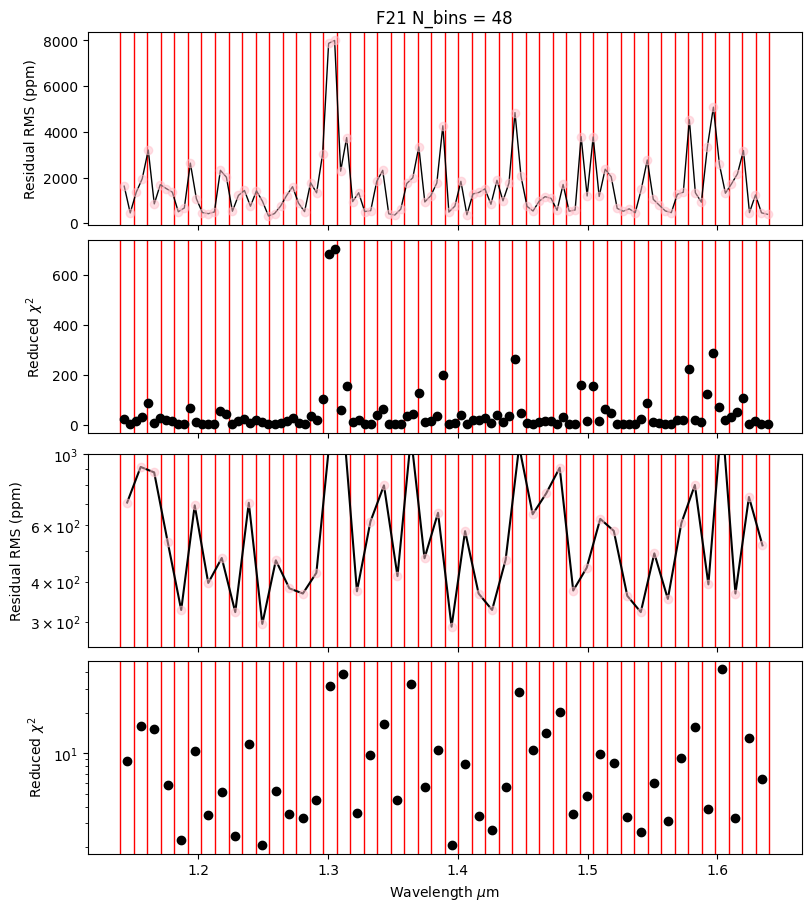

In [10]:
'FOR THE TRANSMISSION LIGHT CURVES'

F21_bin_edges = np.linspace(1.14,1.64,49) * u.micron
# for edge in F21_bin_edges:
    # print(f'{edge.value:.6f}')
bin_testing(visit='F21',
            bin_edges = F21_bin_edges,
            print_results = True,plot=True)

F21_bin_edges = np.linspace(1.14,1.64,42) * u.micron
# for edge in F21_bin_edges:
    # print(f'{edge.value:.6f}')
bin_testing(visit='F21',
            bin_edges = F21_bin_edges,
            print_results = True,plot=True)

F21_bin_edges = np.linspace(1.14,1.64,31) * u.micron
# for edge in F21_bin_edges:
    # print(f'{edge.value:.6f}')
bin_testing(visit='F21',
            bin_edges = F21_bin_edges,
            print_results = True,plot=True)

F21_bin_edges = np.linspace(1.14,1.64,24) * u.micron
# for edge in F21_bin_edges:
    # print(f'{edge.value:.6f}' )
bin_testing(visit='F21',
            bin_edges = F21_bin_edges,
            print_results = True,plot=True)

F21_bin_edges = np.linspace(1.14,1.64,17) * u.micron
# for edge in F21_bin_edges:
    # print(f'{edge.value:.6f}')
bin_testing(visit='F21',
            bin_edges = F21_bin_edges,
            print_results = True,plot=True)

F21_bin_edges =jnp.array([1.14064,1.16381,1.18234,1.20087,
                          1.21477,1.23793,1.25647,1.28426,
                          1.31669,1.33059,1.34449,1.35839,
                          1.39082,1.40935,1.42325,1.43715,
                          1.45568,1.47421,1.51127,1.52980,
                          1.54834,1.57150,1.62246,1.64])*u.micron
bin_testing(visit='F21',
            bin_edges = F21_bin_edges,
            print_results = True,plot=True)

F21_bin_edges = np.array([1.13, 1.159170,1.210135,
                          1.25183, 1.28426,1.325955,
                          1.34912, 1.390815,1.413980, 
                          1.460305, 1.488105,1.5298,
                          1.566865,1.62245,1.64]) * u.micron
bin_testing(visit='F21',
            bin_edges = F21_bin_edges,
            print_results = True,plot=True)

Wavelength Median_rel_err linear_rms r_chisq
0.82183 573 570 1.014
0.82429 554 492 0.813
0.82675 539 584 1.210
0.82921 531 736 1.979
0.83167 524 790 2.342
0.83412 519 704 1.898
0.83658 514 789 2.423
0.83904 509 973 3.764
0.84150 500 839 2.892
0.84396 497 942 3.699
0.84642 492 997 4.238
0.84887 487 1395 8.443
0.85133 485 1426 8.926
0.85379 482 1441 9.205
0.85625 472 849 3.326
0.85871 473 976 4.396
0.86117 467 945 4.210
0.86362 466 966 4.426
0.86608 465 1245 7.383
0.86854 455 815 3.300
0.87100 441 509 1.370
0.87346 430 575 1.835
0.87592 425 652 2.424
0.87838 420 539 1.693
0.88083 419 764 3.418
0.88329 412 531 1.708
0.88575 407 680 2.867
0.88821 405 682 2.921
0.89067 401 583 2.177
0.89313 400 726 3.398
0.89558 393 572 2.178
0.89804 389 556 2.102
0.90050 389 750 3.834
0.90296 388 614 2.577
0.90542 383 577 2.328
0.90788 382 599 2.534
0.91034 377 478 1.656
0.91279 370 405 1.232
0.91525 364 497 1.910
0.91771 361 513 2.078
0.92017 359 583 2.711
0.92263 359 796 5.051
0.92509 358 675 3.656
0.927

🌈🤖 It looks like you're trying to bin in wavelength for a
`Rainbow` object that might not be normalized. In the
current version of `chromatic`, binning before normalizing
might give inaccurate results if the typical uncertainty
varies strongly with wavelength.

Please consider normalizing first, for example with
`rainbow.normalize().bin(...)`
so that all uncertainties will effectively be relative,
and the inverse variance weighting used for binning
wavelengths together will give more reasonable answers.

If you really need to bin before normalizing, please submit
an Issue at github.com/zkbt/chromatic/, and we'll try to
prioritize implementing a statistically sound solution as
soon as possible!



  0%|          | 0/160 [00:00<?, ?it/s]

BINNED: Wavelength Median_rel_err linear_rms r_chisq
0.82258 414 428 1.098
0.82775 370 551 2.284
0.83292 359 661 3.481
0.83808 352 757 4.760
0.84325 343 792 5.490
0.84842 337 1213 13.367
0.85358 331 1247 14.585
0.85875 325 764 5.709
0.86392 321 920 8.445
0.86908 311 693 5.094
0.87425 296 536 3.373
0.87942 289 531 3.470
0.88458 282 546 3.839
0.88975 278 593 4.694
0.89492 272 521 3.765
0.90008 268 618 5.478
0.90525 265 456 3.041
0.91042 259 419 2.694
0.91558 251 422 2.907
0.92075 248 572 5.476
0.92592 246 540 4.957
0.93108 243 460 3.706
0.93625 243 508 4.509
0.94142 239 439 3.477
0.94658 235 433 3.512
0.95175 232 564 6.090
0.95692 230 577 6.503
0.96208 228 483 4.592
0.96725 227 466 4.342
0.97242 225 452 4.142
0.97758 223 423 3.697
0.98275 221 389 3.179
0.98792 222 569 6.730
0.99308 223 533 5.881
0.99825 220 412 3.615
1.00342 219 718 11.073
1.00858 218 597 7.723
1.01375 216 437 4.211
1.01892 215 431 4.139
1.02408 213 390 3.454
1.02925 211 445 4.543
1.03442 212 413 3.914
1.03958 210 368 3.

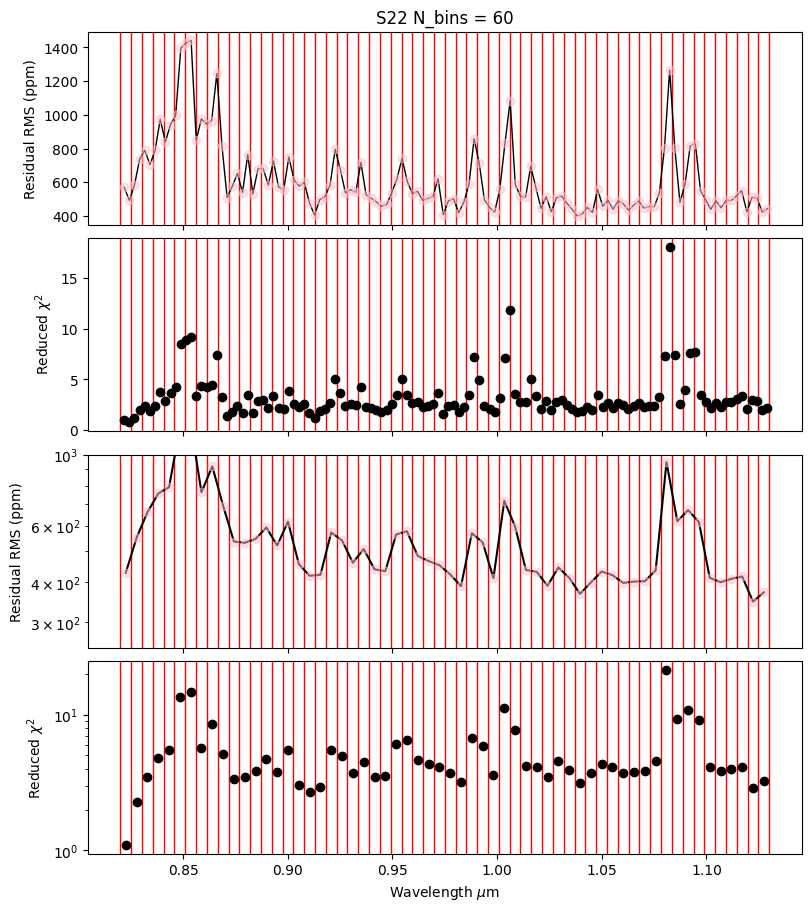

Wavelength Median_rel_err linear_rms r_chisq
0.82183 573 570 1.014
0.82429 554 492 0.813
0.82675 539 584 1.210
0.82921 531 736 1.979
0.83167 524 790 2.342
0.83412 519 704 1.898
0.83658 514 789 2.423
0.83904 509 973 3.764
0.84150 500 839 2.892
0.84396 497 942 3.699
0.84642 492 997 4.238
0.84887 487 1395 8.443
0.85133 485 1426 8.926
0.85379 482 1441 9.205
0.85625 472 849 3.326
0.85871 473 976 4.396
0.86117 467 945 4.210
0.86362 466 966 4.426
0.86608 465 1245 7.383
0.86854 455 815 3.300
0.87100 441 509 1.370
0.87346 430 575 1.835
0.87592 425 652 2.424
0.87838 420 539 1.693
0.88083 419 764 3.418
0.88329 412 531 1.708
0.88575 407 680 2.867
0.88821 405 682 2.921
0.89067 401 583 2.177
0.89313 400 726 3.398
0.89558 393 572 2.178
0.89804 389 556 2.102
0.90050 389 750 3.834
0.90296 388 614 2.577
0.90542 383 577 2.328
0.90788 382 599 2.534
0.91034 377 478 1.656
0.91279 370 405 1.232
0.91525 364 497 1.910
0.91771 361 513 2.078
0.92017 359 583 2.711
0.92263 359 796 5.051
0.92509 358 675 3.656
0.927

🌈🤖 It looks like you're trying to bin in wavelength for a
`Rainbow` object that might not be normalized. In the
current version of `chromatic`, binning before normalizing
might give inaccurate results if the typical uncertainty
varies strongly with wavelength.

Please consider normalizing first, for example with
`rainbow.normalize().bin(...)`
so that all uncertainties will effectively be relative,
and the inverse variance weighting used for binning
wavelengths together will give more reasonable answers.

If you really need to bin before normalizing, please submit
an Issue at github.com/zkbt/chromatic/, and we'll try to
prioritize implementing a statistically sound solution as
soon as possible!



  0%|          | 0/160 [00:00<?, ?it/s]

BINNED: Wavelength Median_rel_err linear_rms r_chisq
0.82298 380 408 1.185
0.82894 341 587 3.045
0.83490 332 658 4.042
0.84087 323 761 5.729
0.84683 315 1060 11.652
0.85279 309 1296 18.067
0.85875 302 753 6.406
0.86471 298 947 10.373
0.87067 285 545 3.778
0.87663 272 520 3.766
0.88260 266 540 4.247
0.88856 259 575 5.063
0.89452 254 527 4.428
0.90048 249 610 6.151
0.90644 245 444 3.356
0.91240 238 382 2.643
0.91837 232 475 4.327
0.92433 229 621 7.533
0.93029 226 450 4.064
0.93625 226 486 4.773
0.94221 222 421 3.716
0.94817 218 457 4.539
0.95413 215 630 8.833
0.96010 213 504 5.763
0.96606 212 457 4.785
0.97202 210 449 4.710
0.97798 208 412 4.061
0.98394 206 389 3.662
0.98990 208 512 6.258
0.99587 206 412 4.114
1.00183 204 590 8.627
1.00779 203 674 11.302
1.01375 201 438 4.877
1.01971 200 433 4.839
1.02567 198 374 3.690
1.03163 197 417 4.612
1.03760 196 370 3.660
1.04356 195 384 3.969
1.04952 196 433 5.037
1.05548 196 418 4.681
1.06144 195 387 4.040
1.06740 194 406 4.505
1.07337 193 404 4

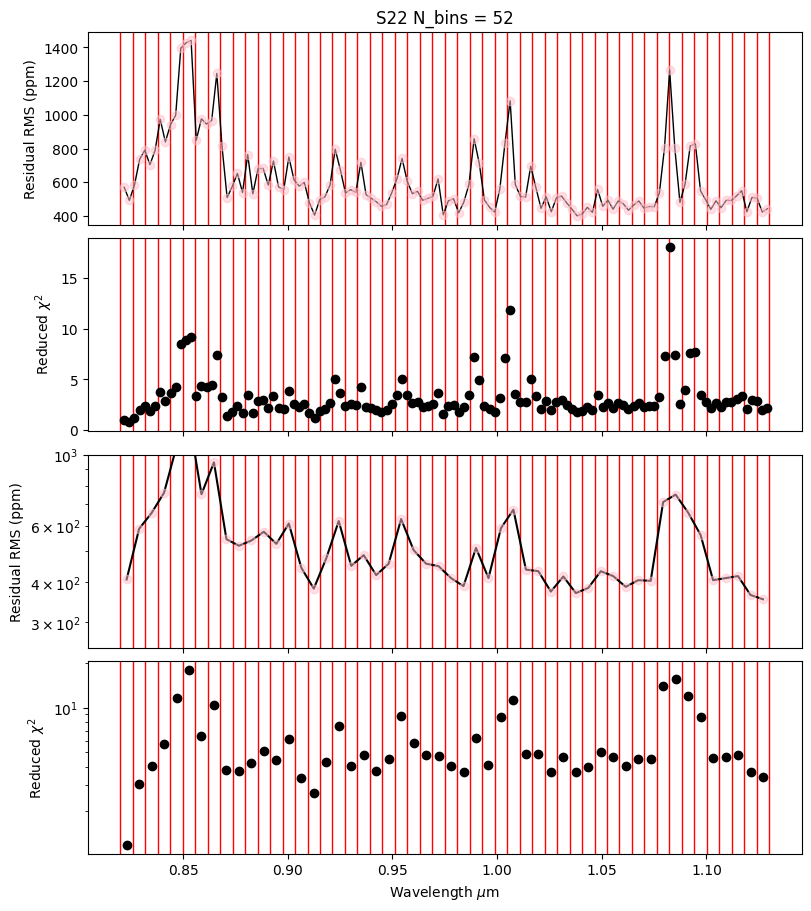

Wavelength Median_rel_err linear_rms r_chisq
0.82183 573 570 1.014
0.82429 554 492 0.813
0.82675 539 584 1.210
0.82921 531 736 1.979
0.83167 524 790 2.342
0.83412 519 704 1.898
0.83658 514 789 2.423
0.83904 509 973 3.764
0.84150 500 839 2.892
0.84396 497 942 3.699
0.84642 492 997 4.238
0.84887 487 1395 8.443
0.85133 485 1426 8.926
0.85379 482 1441 9.205
0.85625 472 849 3.326
0.85871 473 976 4.396
0.86117 467 945 4.210
0.86362 466 966 4.426
0.86608 465 1245 7.383
0.86854 455 815 3.300
0.87100 441 509 1.370
0.87346 430 575 1.835
0.87592 425 652 2.424
0.87838 420 539 1.693
0.88083 419 764 3.418
0.88329 412 531 1.708
0.88575 407 680 2.867
0.88821 405 682 2.921
0.89067 401 583 2.177
0.89313 400 726 3.398
0.89558 393 572 2.178
0.89804 389 556 2.102
0.90050 389 750 3.834
0.90296 388 614 2.577
0.90542 383 577 2.328
0.90788 382 599 2.534
0.91034 377 478 1.656
0.91279 370 405 1.232
0.91525 364 497 1.910
0.91771 361 513 2.078
0.92017 359 583 2.711
0.92263 359 796 5.051
0.92509 358 675 3.656
0.927

🌈🤖 It looks like you're trying to bin in wavelength for a
`Rainbow` object that might not be normalized. In the
current version of `chromatic`, binning before normalizing
might give inaccurate results if the typical uncertainty
varies strongly with wavelength.

Please consider normalizing first, for example with
`rainbow.normalize().bin(...)`
so that all uncertainties will effectively be relative,
and the inverse variance weighting used for binning
wavelengths together will give more reasonable answers.

If you really need to bin before normalizing, please submit
an Issue at github.com/zkbt/chromatic/, and we'll try to
prioritize implementing a statistically sound solution as
soon as possible!



  0%|          | 0/160 [00:00<?, ?it/s]

BINNED: Wavelength Median_rel_err linear_rms r_chisq
0.82387 326 393 1.494
0.83162 295 626 4.634
0.83937 285 719 6.544
0.84712 276 1085 15.889
0.85487 269 1101 17.260
0.86262 263 840 10.514
0.87037 251 618 6.246
0.87812 237 532 5.174
0.88587 229 545 5.810
0.89362 223 525 5.680
0.90137 218 556 6.681
0.90912 213 395 3.550
0.91687 204 433 4.620
0.92462 201 567 8.180
0.93237 198 479 6.010
0.94012 196 443 5.271
0.94787 191 450 5.705
0.95562 188 588 10.080
0.96337 186 459 6.237
0.97112 184 446 6.015
0.97887 182 395 4.855
0.98662 181 476 7.088
0.99437 181 468 6.850
1.00212 179 606 11.804
1.00987 177 532 9.249
1.01762 176 420 5.862
1.02537 173 380 4.924
1.03313 173 411 5.840
1.04087 171 363 4.606
1.04862 172 413 5.946
1.05638 172 409 5.833
1.06412 171 383 5.175
1.07187 170 393 5.515
1.07962 169 754 20.331
1.08737 169 586 12.329
1.09512 169 669 16.023
1.10287 169 397 5.657
1.11062 169 394 5.540
1.11837 170 404 5.808
1.12612 171 344 4.160


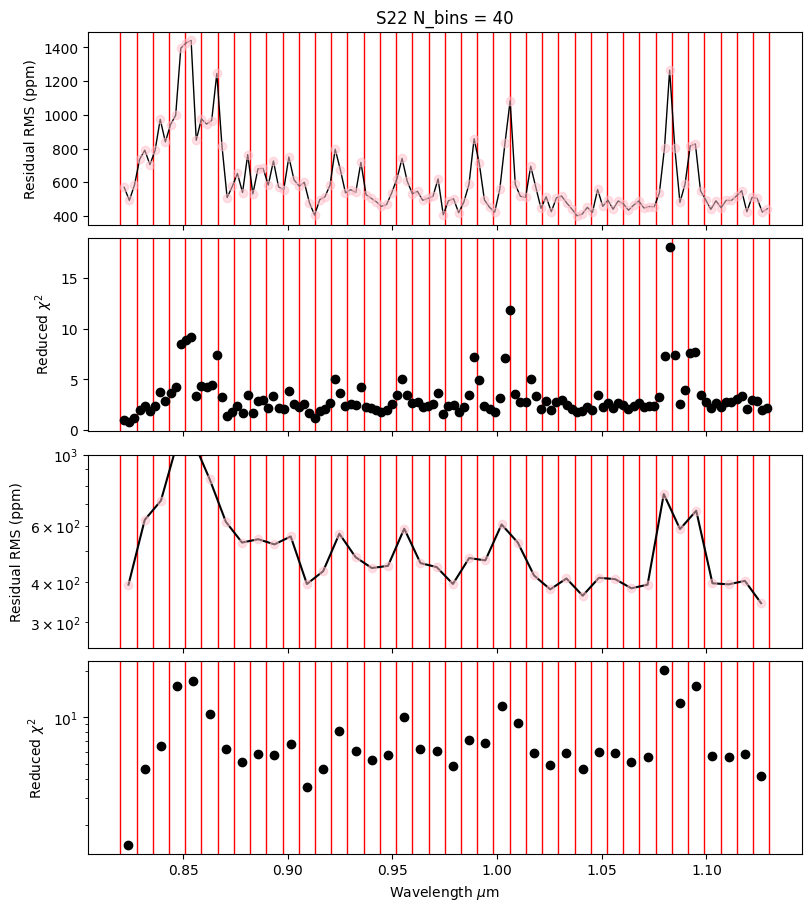

Wavelength Median_rel_err linear_rms r_chisq
0.82183 573 570 1.014
0.82429 554 492 0.813
0.82675 539 584 1.210
0.82921 531 736 1.979
0.83167 524 790 2.342
0.83412 519 704 1.898
0.83658 514 789 2.423
0.83904 509 973 3.764
0.84150 500 839 2.892
0.84396 497 942 3.699
0.84642 492 997 4.238
0.84887 487 1395 8.443
0.85133 485 1426 8.926
0.85379 482 1441 9.205
0.85625 472 849 3.326
0.85871 473 976 4.396
0.86117 467 945 4.210
0.86362 466 966 4.426
0.86608 465 1245 7.383
0.86854 455 815 3.300
0.87100 441 509 1.370
0.87346 430 575 1.835
0.87592 425 652 2.424
0.87838 420 539 1.693
0.88083 419 764 3.418
0.88329 412 531 1.708
0.88575 407 680 2.867
0.88821 405 682 2.921
0.89067 401 583 2.177
0.89313 400 726 3.398
0.89558 393 572 2.178
0.89804 389 556 2.102
0.90050 389 750 3.834
0.90296 388 614 2.577
0.90542 383 577 2.328
0.90788 382 599 2.534
0.91034 377 478 1.656
0.91279 370 405 1.232
0.91525 364 497 1.910
0.91771 361 513 2.078
0.92017 359 583 2.711
0.92263 359 796 5.051
0.92509 358 675 3.656
0.927

🌈🤖 It looks like you're trying to bin in wavelength for a
`Rainbow` object that might not be normalized. In the
current version of `chromatic`, binning before normalizing
might give inaccurate results if the typical uncertainty
varies strongly with wavelength.

Please consider normalizing first, for example with
`rainbow.normalize().bin(...)`
so that all uncertainties will effectively be relative,
and the inverse variance weighting used for binning
wavelengths together will give more reasonable answers.

If you really need to bin before normalizing, please submit
an Issue at github.com/zkbt/chromatic/, and we'll try to
prioritize implementing a statistically sound solution as
soon as possible!



  0%|          | 0/160 [00:00<?, ?it/s]

BINNED: Wavelength Median_rel_err linear_rms r_chisq
0.82517 276 411 2.289
0.83550 251 674 7.394
0.84583 240 982 17.206
0.85617 232 986 18.631
0.86650 224 770 12.219
0.87683 207 504 6.113
0.88717 198 533 7.481
0.89750 191 546 8.417
0.90783 185 399 4.766
0.91817 176 470 7.318
0.92850 173 465 7.460
0.93883 170 449 7.163
0.94917 165 480 8.706
0.95950 162 504 9.988
0.96983 160 437 7.685
0.98017 157 386 6.208
0.99050 157 465 8.997
1.00083 155 547 12.807
1.01117 153 496 10.748
1.02150 151 392 6.927
1.03183 149 394 7.152
1.04217 148 364 6.193
1.05250 149 413 7.923
1.06283 148 382 6.857
1.07317 147 397 7.511
1.08350 146 774 28.576
1.09383 146 631 19.074
1.10417 147 384 7.070
1.11450 147 395 7.414
1.12483 148 346 5.628


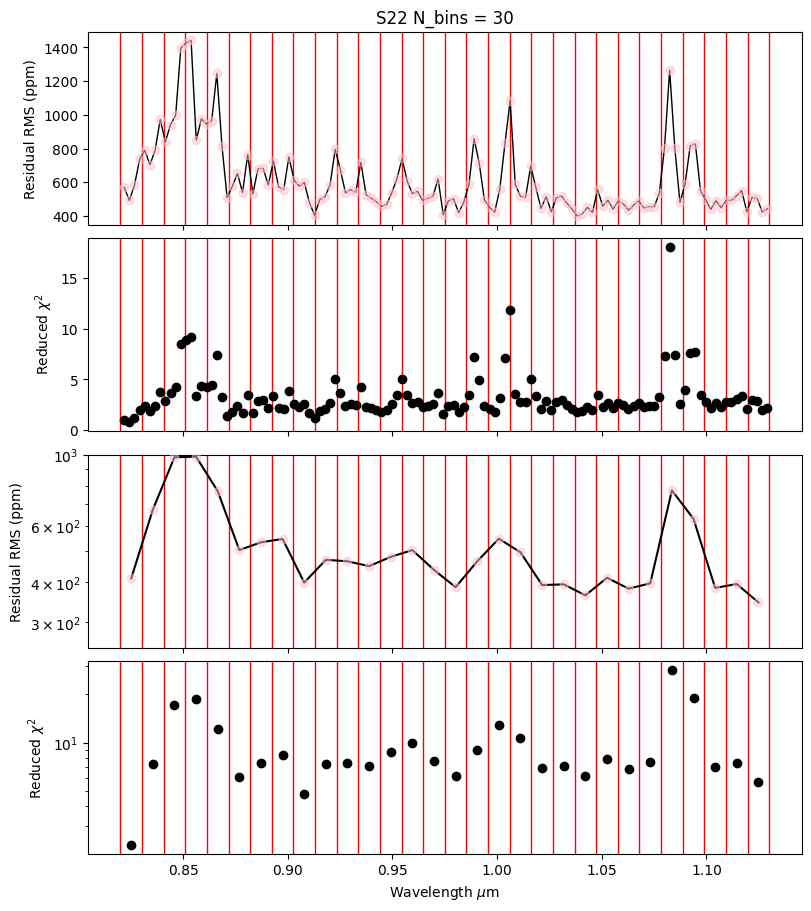

Wavelength Median_rel_err linear_rms r_chisq
0.82183 573 570 1.014
0.82429 554 492 0.813
0.82675 539 584 1.210
0.82921 531 736 1.979
0.83167 524 790 2.342
0.83412 519 704 1.898
0.83658 514 789 2.423
0.83904 509 973 3.764
0.84150 500 839 2.892
0.84396 497 942 3.699
0.84642 492 997 4.238
0.84887 487 1395 8.443
0.85133 485 1426 8.926
0.85379 482 1441 9.205
0.85625 472 849 3.326
0.85871 473 976 4.396
0.86117 467 945 4.210
0.86362 466 966 4.426
0.86608 465 1245 7.383
0.86854 455 815 3.300
0.87100 441 509 1.370
0.87346 430 575 1.835
0.87592 425 652 2.424
0.87838 420 539 1.693
0.88083 419 764 3.418
0.88329 412 531 1.708
0.88575 407 680 2.867
0.88821 405 682 2.921
0.89067 401 583 2.177
0.89313 400 726 3.398
0.89558 393 572 2.178
0.89804 389 556 2.102
0.90050 389 750 3.834
0.90296 388 614 2.577
0.90542 383 577 2.328
0.90788 382 599 2.534
0.91034 377 478 1.656
0.91279 370 405 1.232
0.91525 364 497 1.910
0.91771 361 513 2.078
0.92017 359 583 2.711
0.92263 359 796 5.051
0.92509 358 675 3.656
0.927

🌈🤖 It looks like you're trying to bin in wavelength for a
`Rainbow` object that might not be normalized. In the
current version of `chromatic`, binning before normalizing
might give inaccurate results if the typical uncertainty
varies strongly with wavelength.

Please consider normalizing first, for example with
`rainbow.normalize().bin(...)`
so that all uncertainties will effectively be relative,
and the inverse variance weighting used for binning
wavelengths together will give more reasonable answers.

If you really need to bin before normalizing, please submit
an Issue at github.com/zkbt/chromatic/, and we'll try to
prioritize implementing a statistically sound solution as
soon as possible!



  0%|          | 0/160 [00:00<?, ?it/s]

BINNED: Wavelength Median_rel_err linear_rms r_chisq
0.82738 225 448 4.076
0.84214 204 814 16.348
0.85690 194 974 26.027
0.87167 180 646 13.267
0.88643 166 535 10.641
0.90119 158 488 9.814
0.91595 149 432 8.616
0.93071 144 459 10.438
0.94548 139 433 9.924
0.96024 135 497 13.845
0.97500 132 405 9.599
0.98976 131 427 10.873
1.00452 129 566 19.686
1.01929 127 391 9.782
1.03405 125 370 9.053
1.04881 124 386 9.933
1.06357 124 377 9.542
1.07833 123 620 26.153
1.09310 122 572 22.375
1.10786 123 369 9.301
1.12262 123 354 8.450


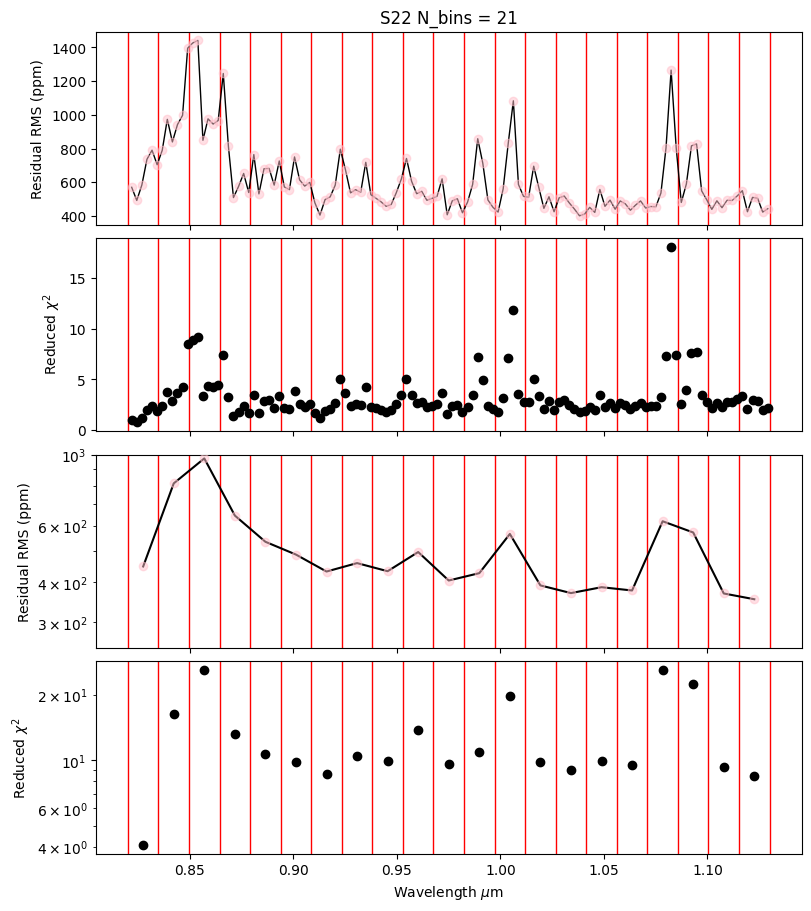

Wavelength Median_rel_err linear_rms r_chisq
0.82183 573 570 1.014
0.82429 554 492 0.813
0.82675 539 584 1.210
0.82921 531 736 1.979
0.83167 524 790 2.342
0.83412 519 704 1.898
0.83658 514 789 2.423
0.83904 509 973 3.764
0.84150 500 839 2.892
0.84396 497 942 3.699
0.84642 492 997 4.238
0.84887 487 1395 8.443
0.85133 485 1426 8.926
0.85379 482 1441 9.205
0.85625 472 849 3.326
0.85871 473 976 4.396
0.86117 467 945 4.210
0.86362 466 966 4.426
0.86608 465 1245 7.383
0.86854 455 815 3.300
0.87100 441 509 1.370
0.87346 430 575 1.835
0.87592 425 652 2.424
0.87838 420 539 1.693
0.88083 419 764 3.418
0.88329 412 531 1.708
0.88575 407 680 2.867
0.88821 405 682 2.921
0.89067 401 583 2.177
0.89313 400 726 3.398
0.89558 393 572 2.178
0.89804 389 556 2.102
0.90050 389 750 3.834
0.90296 388 614 2.577
0.90542 383 577 2.328
0.90788 382 599 2.534
0.91034 377 478 1.656
0.91279 370 405 1.232
0.91525 364 497 1.910
0.91771 361 513 2.078
0.92017 359 583 2.711
0.92263 359 796 5.051
0.92509 358 675 3.656
0.927

🌈🤖 It looks like you're trying to bin in wavelength for a
`Rainbow` object that might not be normalized. In the
current version of `chromatic`, binning before normalizing
might give inaccurate results if the typical uncertainty
varies strongly with wavelength.

Please consider normalizing first, for example with
`rainbow.normalize().bin(...)`
so that all uncertainties will effectively be relative,
and the inverse variance weighting used for binning
wavelengths together will give more reasonable answers.

If you really need to bin before normalizing, please submit
an Issue at github.com/zkbt/chromatic/, and we'll try to
prioritize implementing a statistically sound solution as
soon as possible!



  0%|          | 0/160 [00:00<?, ?it/s]

BINNED: Wavelength Median_rel_err linear_rms r_chisq
0.82153 573 570 1.014
0.82675 312 470 2.329
0.85010 122 844 49.349
0.87469 214 481 5.177
0.88452 205 545 7.267
0.89681 160 539 11.628
0.90788 219 408 3.547
0.91648 182 416 5.381
0.92754 158 495 10.039
0.94107 141 426 9.327
0.95459 149 541 13.490
0.96442 191 453 5.790
0.97057 232 508 4.935
0.97548 230 418 3.407
0.98163 185 385 4.443
1.00007 92 482 28.315
1.01974 155 412 7.228
1.02834 177 385 4.863
1.03449 217 416 3.785
1.04063 176 365 4.426
1.05047 136 401 8.911
1.06153 152 386 6.617
1.07013 174 402 5.479
1.08734 90 614 47.097
1.10701 134 376 8.032
1.11807 151 392 6.943
1.12650 180 348 3.853


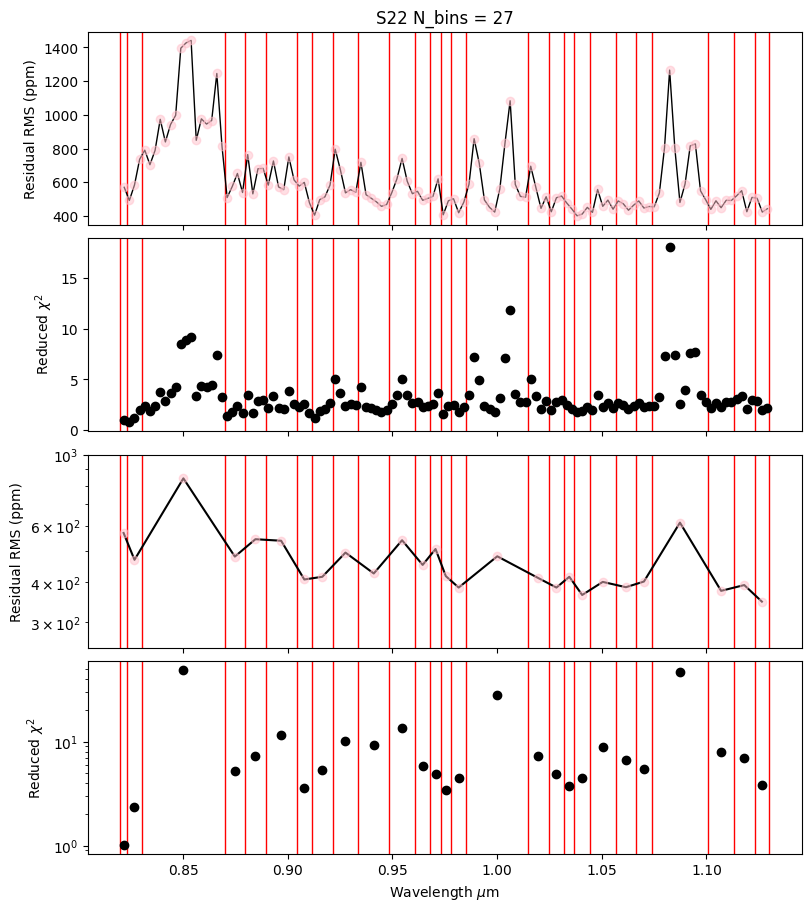

[570,
 470,
 844,
 481,
 545,
 539,
 408,
 416,
 495,
 426,
 541,
 453,
 508,
 418,
 385,
 482,
 412,
 385,
 416,
 365,
 401,
 386,
 402,
 614,
 376,
 392,
 348]

In [6]:
S22_bin_edges = np.linspace(0.82,1.13,61) * u.micron
# for edge in S22_bin_edges:
#     print(f'{edge.value:.6f}')
bin_testing(visit='S22',bin_edges = S22_bin_edges,
        print_results = True,plot=True)

S22_bin_edges = np.linspace(0.82,1.13,53) * u.micron
# for edge in S22_bin_edges:
#     print(f'{edge.value:.6f}')
bin_testing(visit='S22',bin_edges = S22_bin_edges,
        print_results = True,plot=True)

S22_bin_edges = np.linspace(0.82,1.13,41) * u.micron
# for edge in S22_bin_edges:
#     print(f'{edge.value:.6f}')
bin_testing(visit='S22',bin_edges = S22_bin_edges,
        print_results = True,plot=True)

S22_bin_edges = np.linspace(0.82,1.13,31) * u.micron
# for edge in S22_bin_edges:
#     print(f'{edge.value:.6f}')
bin_testing(visit='S22',bin_edges = S22_bin_edges,
        print_results = True,plot=True)

S22_bin_edges = np.linspace(0.82,1.13,22) * u.micron
# for edge in S22_bin_edges:
#     print(f'{edge.value:.6f}')
bin_testing(visit='S22',bin_edges = S22_bin_edges,
        print_results = True,plot=True)

S22_bin_edges = np.array([0.82, 0.82306047, 0.8304358 ,0.8697709 , 
                          0.87960467,0.88943845, 0.90418911,0.91156444, 
                          0.92139821, 0.93369043, 0.94844109, 0.96073331, 
                          0.96810864, 0.97302553, 0.97794241,0.98531775,
                          1.01481907,1.02465284, 1.03202817, 1.03694506, 
                          1.04432039, 1.05661261, 1.06644638, 1.07382171, 
                          1.10086459,1.11315681,1.12299059, 1.13]) * u.micron
bin_testing(visit='S22',bin_edges = S22_bin_edges,
        print_results = True,plot=True)